In [7]:
import numpy as np
import matplotlib.pyplot as plt

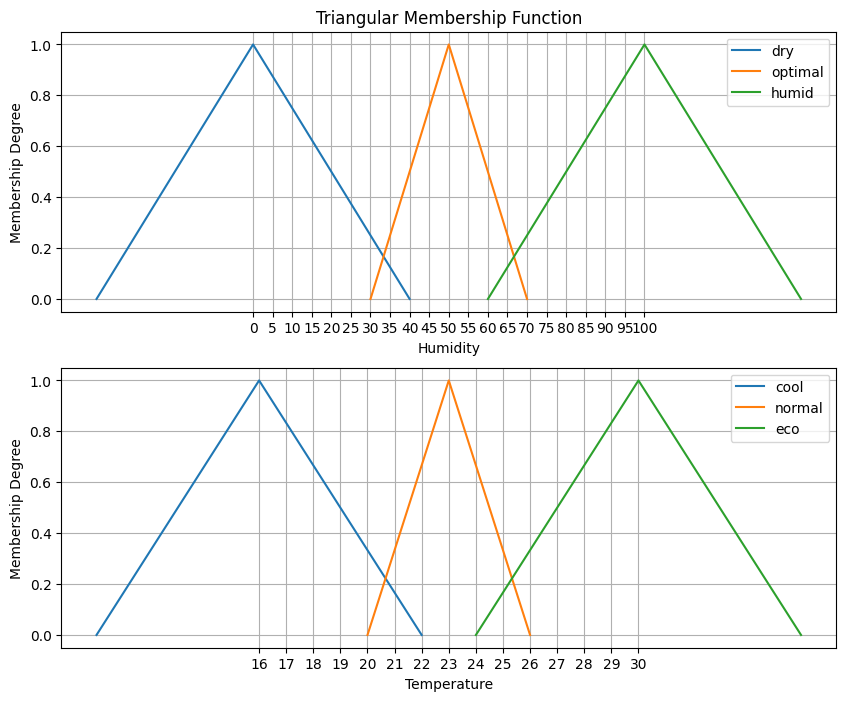

In [8]:
# Input Define:
n=1+1
humidity={
    'dry':[-40,40],
    'optimal':[30,70],
    'humid':[60,140]
}

# Output Define:
temperature={
    'cool':[10,22],
    'normal':[20,26],
    'eco':[24,36]
}

y=[0,1,0]
plt.figure(figsize=(10,8))
plt.subplot(n,1,1)
plt.xticks(np.arange(0,105,5))
plt.grid(True)
plt.title('Triangular Membership Function')
plt.xlabel('Humidity')
plt.ylabel('Membership Degree')
for i,j in humidity.items():
    x=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()

plt.subplot(n,1,2)
plt.xticks(np.arange(16,31,1))
plt.grid(True)
plt.xlabel('Temperature')
plt.ylabel('Membership Degree')
for i,j in temperature.items():
    x=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()
    
plt.show()

In [9]:
def rules(value):
    if(value=='optimal'):
        return np.sum(temperature['normal'])/2
    elif(value=='humid'):
        return np.sum(temperature['eco'])/2
    elif(value=='dry'):
        return np.sum(temperature['cool'])/2
    
    

In [10]:
def membership_degree(x,s):
    a=humidity[s][0] # minimum value
    b=np.sum(humidity[s])/2 # mid value
    c=humidity[s][1] #max value
    if x>=c:
        return 0
    if x>b:
        return (c-x)/(c-b)
    if x>a:
        return (x-a)/(b-a)
    else:
        return 0

In [11]:
def Fuzzy(x):
    membership_value=[]
    for i,j in humidity.items():
        result=membership_degree(x,i) # take the membership value from given input
        membership_value.append(result)

    print(membership_value)

    crisp_temp=[]
    for i in humidity:
        crisp_temp.append(rules(i)) # storing the rule
    
    print(crisp_temp)
        
    crisp_temp=np.array(crisp_temp)
    try:
        crisp_temp=crisp_temp*np.array(membership_value) #multiplication
        crisp_temp=np.sum(crisp_temp)/np.sum(membership_value) # Divide
    except:
        crisp_temp=0
    return crisp_temp


In [16]:
x=35
print(f"{Fuzzy(x):.3f}")

[np.float64(0.125), np.float64(0.25), 0]
[np.float64(16.0), np.float64(23.0), np.float64(30.0)]
20.667
